<a href="https://colab.research.google.com/github/rogeraclaro/AI-Bookmark-Manager/blob/main/Workshop_Google_ADK_Multiagents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building Your First Multi-Agent System with Google ADK

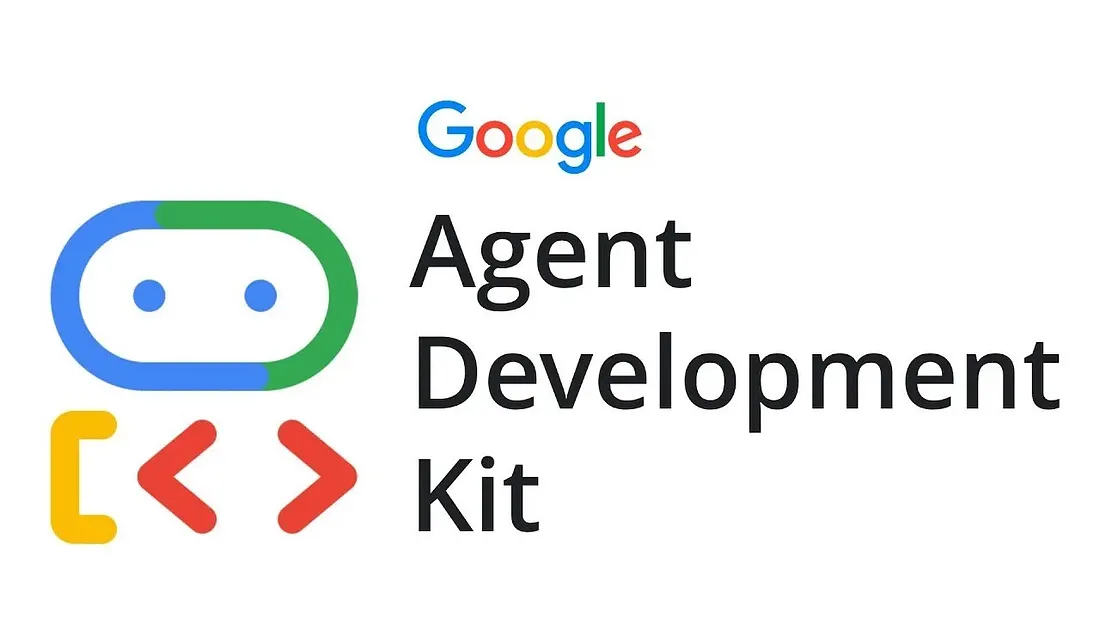

* **Author of this Google Colab**: [Fabrício Carraro](https://www.linkedin.com/in/fabriciocarraro)

Welcome! In this hands-on class you'll build two multi-agent systems with Google ADK:

1. A **briefing generator** that researches any topic on the web, then summarizes it from multiple angles in parallel.
2. An **internal company assistant** that routes employee questions to the right specialist: internal HR policies (via RAG) or the public web, depending on what's being asked.

By the end you'll understand:

- `LlmAgent`: the core building block
- **Custom tools** vs **built-in tools** (`google_search`)
- `SequentialAgent`: chaining agents in a pipeline
- `ParallelAgent`: fanning out work for speed
- **Agent routing**: an LLM-powered router delegating to specialist sub-agents
- **RAG**: giving an agent a retrieval tool over a private corpus (with `gemini-embedding-001`)
- **Session state**: how agents share information
- The `Runner` execution model

## 1. Setup

We need two things: the ADK Python package and a **Gemini API key**. Google ADK already comes installed on Google Colab, but you'll have to install it in your local run.

Get a free API key at https://aistudio.google.com/apikey

In [ ]:
# Configure your Gemini API key
# In Colab: click the 🔑 (key) icon on the left sidebar, add a secret named 'GOOGLE_API_KEY',
# then enable "Notebook access". This cell will pick it up automatically.
import os

from google.colab import userdata
os.environ["GOOGLE_API_KEY"] = userdata.get("GEMINI_API_KEY")

## 2. A helper function to run agents

ADK's `Runner` is asynchronous and streams **events** (tool calls, partial responses, the final answer). In Colab the event loop is already running, so we can use `await` directly in cells.

The helper below wraps the boilerplate: create a session, send the user message, stream events, and return the final text response.

In [ ]:
MODEL = "gemini-2.5-flash"  # Fast and cheap
APP_NAME = "briefing_app"
USER_ID = "student"

In [ ]:
from google.adk.runners import Runner
from google.adk.sessions import InMemorySessionService
from google.genai import types

async def run_agent(agent, user_message: str, verbose: bool = True) -> str:
    """Run an agent with a single user message and return the final response text.

    If verbose=True, prints each event as it streams (great for understanding what's happening).
    """
    session_service = InMemorySessionService()
    session = await session_service.create_session(
        app_name=APP_NAME, user_id=USER_ID
    )
    runner = Runner(
        agent=agent, app_name=APP_NAME, session_service=session_service
    )

    content = types.Content(role="user", parts=[types.Part(text=user_message)])
    final_response = ""

    async for event in runner.run_async(user_id=USER_ID, session_id=session.id, new_message=content):
        # Each event tells us what an agent did: called a tool, produced text, etc.
        if verbose:
            author = event.author or "system"

            # Built-in grounding tools (like google_search) run inside the model,
            # not in our Python runtime. They don't emit function_call/function_response
            # events, but attach grounding_metadata to the text event instead.
            # We render them with the same 🔧/📥 markers as regular tools so the trace
            # stays consistent — semantically, it's still "the agent used a tool".
            grounding = getattr(event, "grounding_metadata", None)
            if grounding and getattr(grounding, "grounding_chunks", None):
                # Collect unique source titles (multiple chunks often come from the same domain)
                sources = []
                seen = set()
                for c in grounding.grounding_chunks:
                    web = getattr(c, "web", None)
                    title = getattr(web, "title", None) if web else None
                    if title and title not in seen:
                        seen.add(title)
                        sources.append(title)
                if sources:
                    print(f"🔧 [{author}] called tool: google_search")
                    preview = ", ".join(sources[:3])
                    extra = f", +{len(sources) - 3} more" if len(sources) > 3 else ""
                    print(f"📥 [{author}] tool response: {len(sources)} source(s) ({preview}{extra})")

            if event.content and event.content.parts:
                for part in event.content.parts:
                    if part.function_call:
                        print(f"🔧 [{author}] called tool: {part.function_call.name}({dict(part.function_call.args)})")
                    elif part.function_response:
                        print(f"📥 [{author}] tool response received")
                    elif part.text:
                        snippet = part.text[:120].replace("\n", " ")
                        print(f"💬 [{author}]: {snippet}{'...' if len(part.text) > 120 else ''}")

        if event.is_final_response() and event.content and event.content.parts:
            final_response = event.content.parts[0].text or ""

    return final_response

## 3. Your first agent — with a custom tool

Let's start simple. An agent is just three things:

1. A **model** (`gemini-2.5-flash`)
2. An **instruction** (system prompt)
3. Optional **tools** (Python functions the agent can call)

ADK turns any Python function into a tool automatically. It reads the **function signature** (parameter types) and the **docstring** to know when and how to call it.

In [ ]:
def get_word_count(text: str) -> dict:
    """Counts the number of words in a piece of text.

    Use this whenever the user asks how long, how many words, or for word count of any text.

    Args:
        text: The text to count words in.

    Returns:
        A dict with the word count and the text length in characters.
    """
    words = text.split()
    return {
        "word_count": len(words),
        "character_count": len(text),
    }

In [ ]:
from google.adk.agents import LlmAgent

word_counter_agent = LlmAgent(
    name="word_counter",
    model=MODEL,
    description="An assistant that can count words in text.",
    instruction=(
        """You are a helpful assistant. When the user gives you text to analyze,
        use the get_word_count tool. Always report the exact numbers from the tool."""
    ),
    tools=[get_word_count],
)

In [ ]:
# Test it
response = await run_agent(
    word_counter_agent,
    "How many words are in this sentence: 'The quick brown fox jumps over the lazy dog'?"
)
print("\n" + "="*60)
print("FINAL RESPONSE:\n", response)

🔧 [word_counter] called tool: get_word_count({'text': 'The quick brown fox jumps over the lazy dog'})
📥 [word_counter] tool response received
💬 [word_counter]: The sentence "The quick brown fox jumps over the lazy dog" contains 9 words and 43 characters.

FINAL RESPONSE:
 The sentence "The quick brown fox jumps over the lazy dog" contains 9 words and 43 characters.


**What just happened:**

1. The user asked a question.
2. Gemini saw the `get_word_count` tool in context, decided it was relevant, and called it with the right argument.
3. ADK executed the Python function and fed the result back to Gemini.
4. Gemini wrote the final natural-language response.

This loop — *think → call tool → observe result → respond* — is the heart of every agent.

## 4. Adding web search

For real research, we need fresh information from the web. ADK ships with `google_search`, a built-in tool backed by Google's grounding feature.

> ⚠️ **Important limitation**: `google_search` cannot be combined with custom tools or other built-in tools in the same `LlmAgent`. If you need both, you wrap the search agent inside an `AgentTool`. For our pipeline we don't need to mix, as the researcher will be search-only, but we're going to face this issue later.

In [ ]:
from google.adk.tools import google_search

researcher = LlmAgent(
    name="researcher",
    model=MODEL,
    description="Researches a topic on the web and produces raw findings.",
    instruction=(
        """You are a tech researcher. Given a topic from the user, use the google_search tool
        to find 4-6 recent and credible sources. Then produce a structured raw notes
        document with:
        1) A list of key facts (with source URLs in parentheses).
        2) Notable quotes or numbers.
        3) Any disagreements between sources.
        Do NOT write a polished article — just structured notes for a downstream editor."""
    ),
    tools=[google_search],
)

In [ ]:
# Try it on a real topic
response = await run_agent(
    researcher,
    "Topic: the release of Gemini Omni — when, what is it, how was it received?",
    verbose=True,
)
print("\n" + "="*60)
print("RESEARCH NOTES:\n", response[:1500], "..." if len(response) > 1500 else "")

🔧 [researcher] called tool: google_search
📥 [researcher] tool response: 12 source(s) (cnet.com, venturebeat.com, google.com, +9 more)
💬 [researcher]: Here are structured raw notes on Gemini Omni:  ### Gemini Omni: Raw Notes  **1. Key Facts:**  *   **Release Date:** Gemi...

RESEARCH NOTES:
 Here are structured raw notes on Gemini Omni:

### Gemini Omni: Raw Notes

**1. Key Facts:**

*   **Release Date:** Gemini Omni was officially announced and debuted at the Google I/O conference on Tuesday, May 19, 2026. The initial variant, Gemini Omni Flash, began rolling out on the same day.
*   **Availability:**
    *   Currently available to paid Google AI Plus, Pro, and Ultra subscribers within the Gemini app and Google Flow.
    *   Will launch in YouTube Shorts and the YouTube Create app later this week (the week of May 19, 2026) at no cost.
    *   APIs for developers and enterprise customers are expected in the coming weeks.
*   **Core Functionality:** Gemini Omni is Google DeepMind's first

Notice the trace: the agent made one or more `google_search` calls before writing its notes. Each call hits Google's grounding service and returns snippets that get folded into context.

## 5. Chaining agents with `SequentialAgent`

A single agent that does research AND writing AND editing all at once tends to be mediocre at all three. The solution: **specialization**. Each agent does one thing well, then hands off.

ADK's `SequentialAgent` runs sub-agents **in order**, and they communicate through **session state**, a shared dict where each agent writes results that the next can read.

The mechanism:

- An `LlmAgent` with `output_key="my_key"` automatically writes its final response into `session.state["my_key"]`.
- A downstream agent's instruction can read it back with `{my_key}` (or `{my_key?}` if optional).

Let's build a 2-step pipeline first: **Researcher → Editor**.

In [ ]:
# Update the researcher to save its findings to state
researcher = LlmAgent(
    name="researcher",
    model=MODEL,
    description="Researches a topic on the web and produces raw findings.",
    instruction=(
        """You are a tech researcher. Given a topic from the user, use the google_search tool
        to find 4-6 recent and credible sources. Produce structured raw notes with:
        key facts (with URLs), notable quotes/numbers, and disagreements between sources.
        Output structured notes only — no polished prose."""
    ),
    tools=[google_search],
    output_key="research_findings",  # ← writes to session.state["research_findings"]
)

# Editor reads from state via {research_findings} template
editor = LlmAgent(
    name="editor",
    model=MODEL,
    description="Turns raw research notes into a polished briefing.",
    instruction=(
        """You are a tech editor. Below are raw research notes from your researcher:

        \n\n
        <notes>\n
        {research_findings}
        \n</notes>
        \n\n

        Write a clean, structured briefing in markdown with:
        a one-sentence TL;DR, then 3-4 short paragraphs covering the key angles.
        Cite specific sources inline like [source: domain.com].
        Be concise and concrete. No filler phrases."""
    ),
    output_key="final_briefing",
)

In [ ]:
from google.adk.agents import SequentialAgent

# Wire them up
father_agent = SequentialAgent(
    name="briefing_pipeline_v1",
    sub_agents=[researcher, editor],
    description="Researches a topic and writes a briefing.",
)

In [ ]:
response = await run_agent(
    father_agent,
    "Topic: state of open-source small language models (under 10B params) in 2026",
    verbose=True,
)
print("\n" + "="*60)
print("FINAL BRIEFING:\n", response)

🔧 [researcher] called tool: google_search
📥 [researcher] tool response: 13 source(s) (bentoml.com, localaimaster.com, secondtalent.com, +10 more)
💬 [researcher]: ## State of Open-Source Small Language Models (under 10B params) in 2026  ### Key Facts:  *   **Definition & Importance:...
💬 [editor]: ## State of Open-Source Small Language Models (under 10B params) in 2026  **TL;DR:** Small Language Models (SLMs) under ...

FINAL BRIEFING:
 ## State of Open-Source Small Language Models (under 10B params) in 2026

**TL;DR:** Small Language Models (SLMs) under 10 billion parameters are rapidly becoming foundational for AI products in 2026, offering significant performance, cost, and deployment advantages over larger models for many tasks, despite some licensing and parameter definition nuances.

SLMs, defined as models typically under 10 billion parameters, are now crucial for practical AI due to their efficiency and ability to run in resource-constrained environments like mobile phones, edge

See how the researcher's `google_search` calls fire first, then the editor speaks (with no tool calls, it's pure writing) and produces the final markdown briefing.

If you inspect `session.state` after the run, you'd find both `research_findings` (raw notes) and `final_briefing` (polished output) stored as keys.

## 6. Speeding things up with `ParallelAgent`

What if we want **two different views** of the same research (say, a narrative summary AND a bullet-point list of key takeaways)? Running them sequentially is wasteful: they don't depend on each other.

`ParallelAgent` runs its sub-agents **concurrently**. Each writes to its own state key. A downstream agent then gathers and synthesizes.

This is the classic **fan-out / gather** pattern:

```
                     ┌── Summarizer  ─► state['summary']
research_findings ──►│                                    ──► Editor reads both
                     └── KeyPoints   ─► state['key_points']
```

> ⚠️ **Race conditions warning**: parallel agents share the same `session.state`. Always give them **distinct `output_key`s** so they don't overwrite each other.

In [ ]:
researcher = LlmAgent(
    name="researcher",
    model=MODEL,
    description="Researches a topic on the web and produces raw findings.",
    instruction=(
        """You are a tech researcher. Given a topic from the user, use the google_search tool
        to find 4-6 recent and credible sources. Produce structured raw notes with:
        key facts (with URLs), notable quotes/numbers, and disagreements between sources.
        Output structured notes only — no polished prose."""
    ),
    tools=[google_search],
    output_key="research_findings",  # ← writes to session.state["research_findings"]
)

summarizer = LlmAgent(
    name="summarizer",
    model=MODEL,
    description="Writes a narrative summary from research notes.",
    instruction=(
        """Below are research notes:\n\n
        <notes>\n
        {research_findings}
        \n</notes>
        \n\n
        Write a 2-paragraph narrative summary. No bullets. No headers.
        Focus on the story: what's the situation, why does it matter."""
    ),
    output_key="summary",
)

key_points = LlmAgent(
    name="key_points",
    model=MODEL,
    description="Extracts key takeaways as bullets.",
    instruction=(
        """Below are research notes:\n\n
        <notes>\n
        {research_findings}
        \n</notes>
        \n\n
        Extract exactly 5 key takeaways as a markdown bullet list.
        Each bullet: one sentence, concrete and specific. No fluff."""
    ),
    output_key="key_points",
)

In [ ]:
from google.adk.agents import ParallelAgent

# Fan-out: these two run in parallel
analysis_fanout = ParallelAgent(
    name="analysis_fanout",
    sub_agents=[summarizer, key_points],
    description="Produces summary and key points from research findings in parallel.",
)

Now the final editor reads **both** keys and assembles the briefing.

In [ ]:
final_editor = LlmAgent(
    name="final_editor",
    model=MODEL,
    description="Assembles the final briefing from summary and key points.",
    instruction=(
        """You are assembling a tech briefing. You have two inputs:\n\n
        <summary>\n
        {summary}\n
        </summary>\n\n

        <key_points>\n
        {key_points}
        \n</key_points>
        \n\n

        Combine them into a polished markdown briefing with this structure:\n
          # [Topic title]\n
          **TL;DR:** one sentence.\n
          ## Overview\n
          (the narrative summary)\n
          ## Key Takeaways\n
          (the bullet points)\n\n
        Polish the prose where needed. Keep it tight."""
    ),
    output_key="final_briefing",
)

## 7. Putting it all together

Final architecture:

```
SequentialAgent (root)
  ├── researcher          (google_search → research_findings)
  ├── ParallelAgent       
  │     ├── summarizer    (→ summary)
  │     └── key_points    (→ key_points)
  └── final_editor        (reads summary + key_points → final_briefing)
```

In [ ]:
briefing_generator = SequentialAgent(
    name="briefing_generator",
    sub_agents=[
        researcher,        # step 1: research
        analysis_fanout,   # step 2: parallel summary + key points
        final_editor,      # step 3: assemble
    ],
    description="End-to-end tech topic briefing generator.",
)

In [ ]:
# Run the full thing
TOPIC = "Topic: what is an AI harness? Connect with Google Antigravity."

response = await run_agent(briefing_generator, TOPIC, verbose=True)

print("\n" + "="*60)
print("FINAL BRIEFING")
print("="*60)
print(response)

🔧 [researcher] called tool: google_search
📥 [researcher] tool response: 12 source(s) (salesforce.com, mindstudio.ai, aiquinta.ai, +9 more)
💬 [researcher]: Here are the structured notes on "AI harness" and its connection to "Google Antigravity":  ### Key Facts  **What is an A...
💬 [summarizer]: An AI agent harness serves as the essential operational software layer that encases an AI model, transforming it from a ...
💬 [key_points]: *   An AI agent harness is the operational software layer that manages an AI model's tools, memory, and safety to enable...
💬 [final_editor]: # The AI Agent Harness and Google Antigravity  **TL;DR:** An AI agent harness is the essential operational software laye...

FINAL BRIEFING
# The AI Agent Harness and Google Antigravity

**TL;DR:** An AI agent harness is the essential operational software layer that transforms a text-generating AI model into a capable, autonomous agent, a core architectural component powering Google's "agent-first" Antigravity developme

You should see, in order:

1. The **researcher** firing one or more `google_search` calls.
2. The **summarizer** and **key_points** agents both speaking (their events may interleave, that's parallel execution).
3. The **final_editor** producing the assembled briefing.

That's a real multi-agent system. ~80 lines of agent definitions, no orchestration code, ADK handles the wiring.

## 8. Routing queries — an internal assistant that knows where to look

So far our researcher uses `google_search`, and it knows the public web. But what if you're building an **internal employee assistant** at a tech company? When someone asks "how many vacation days do I get?", the answer isn't on the web, it's in your HR policies. When they ask "what did Google announce at I/O?", the answer isn't in your internal docs, it's on the web.

You need **two specialists** (one for each kind of question) **and a router** that decides which specialist gets the query.

This is the canonical pattern for any internal assistant: an LLM-powered router reading a question, classifying it, and delegating to the right tool or agent. The ADK supports this natively through **agent transfer**, a parent `LlmAgent` declares `sub_agents=[...]` and the LLM picks one based on each sub-agent's `description`.

```
LlmAgent (router)
│
│  Reads each sub-agent's description, picks one based on the query.
│
├── web_researcher       (description: "industry news, tech announcements, external info")
│       └── tools: google_search
│
└── internal_researcher  (description: "Acme Tech policies, HR, benefits, internal docs")
        └── tools: search_internal_docs  (RAG over our policy corpus)
```

We'll build this in five steps: a fictional company's policy corpus, embeddings for it, the RAG tool, the two specialist agents, and the router that ties them together.

### 8.1 The corpus — Acme Tech's internal policies

A fictional Barcelona-based tech company, **Acme Tech**, with 6 internal policy documents covering remote work, vacation, parental leave, compensation, L&D budget, and health benefits. None of this is on the public web, that's the whole point of using RAG over a private corpus.

**What's RAG?**

RAG stands for **Retrieval-Augmented Generation**. The idea: instead of relying on what the LLM already knows (its training data) or what it can search online, you give it access to *your own* documents, and let it retrieve the most relevant pieces on demand.
>
> The flow is always the same three steps:
> 1. **Index**: convert your documents into embeddings once, store them.
> 2. **Retrieve**: when a question comes in, embed it and find the most similar documents.
> 3. **Generate**: feed those retrieved documents to the LLM as context, then let it answer.
>
> This is how you build assistants that know about *your* company's HR policies, *your* product docs, *your* meeting notes, anything the model couldn't have seen during training. It's the dominant pattern for internal knowledge assistants in production today.

In [ ]:
INTERNAL_DOCS = [
    {
        "title": "Remote work policy (effective Jan 2026)",
        "text": (
            "Acme Tech operates on a hybrid model: 2 days minimum in-office per week "
            "for Barcelona-based employees, fully remote allowed for employees living "
            "more than 60km from the office. Core collaboration hours are 10:00-15:00 "
            "CET — meetings must fit within this window to accommodate teammates in "
            "São Paulo (-4h) and Bangalore (+3h30). Async-first culture: written "
            "decisions in Notion are mandatory before any synchronous meeting longer "
            "than 30 minutes. Right-to-disconnect enforced: no Slack notifications "
            "between 19:00 and 09:00 CET, weekends excluded entirely."
        ),
    },
    {
        "title": "Vacation and time off (2026 update)",
        "text": (
            "All full-time employees receive 26 working days of paid vacation per year, "
            "above the Spanish legal minimum of 22. Vacation accrues monthly (2.16 days/month) "
            "and can be carried over up to 5 days into the next year, expiring on March 31. "
            "Additionally: 14 public holidays per year (Barcelona calendar), 5 paid sick "
            "days with no doctor\'s note required, and 2 \'mental health days\' per quarter "
            "for self-declared use. Sabbatical eligibility: 4 weeks paid after 4 years of "
            "tenure, repeatable every 4 years."
        ),
    },
    {
        "title": "Parental leave and family policy",
        "text": (
            "Acme Tech extends Spanish statutory parental leave: 20 weeks fully paid for "
            "the birthing parent (vs 16 weeks legal minimum), 16 weeks for the non-birthing "
            "parent with extended flexibility. Adoption and foster care receive identical "
            "treatment. Phased return: parents can work 60% schedule at 80% pay for the "
            "first 3 months after returning. Childcare stipend of EUR 350/month per child "
            "under 3 years old. Fertility treatment coverage up to EUR 8,000 lifetime per "
            "employee through partnership with Clínica Eugin."
        ),
    },
    {
        "title": "Compensation and equity (Q1 2026 framework)",
        "text": (
            "Salary bands published internally on the wiki — full transparency across all "
            "engineering levels (E2 through E7). Annual reviews in March; cost-of-living "
            "adjustments tied to Spanish CPI (3.1% applied in 2026). Equity: 4-year vesting "
            "with 1-year cliff, monthly vesting thereafter. New hires receive RSUs equivalent "
            "to 15-25% of base salary depending on level. Annual refresh grants of 5-10% of "
            "base salary for employees meeting performance bar. Bonus pool: 12% of base, "
            "tied to company OKRs (60%) and individual performance (40%)."
        ),
    },
    {
        "title": "Learning and development budget",
        "text": (
            "Annual L&D budget: EUR 2,500 per employee, no manager approval required for "
            "spend under EUR 500. Covers conferences, courses, books, certifications. "
            "Conference travel additionally reimbursed: 2 international conferences per "
            "year (flight + hotel + tickets). Internal speaker program: employees who "
            "present at external conferences receive EUR 500 bonus per accepted talk. "
            "Language learning: full reimbursement for Catalan or Spanish classes for "
            "international hires (up to EUR 1,200/year). 10% time policy: every Friday "
            "afternoon reserved for learning, side projects, or internal hackathons."
        ),
    },
    {
        "title": "Health and wellness benefits (2026)",
        "text": (
            "Private health insurance through Sanitas, fully covered for employee and "
            "spouse/partner, 50% covered for children. Includes dental and mental health "
            "(unlimited therapy sessions). Gym stipend EUR 60/month, redeemable at any "
            "facility or via apps like ClassPass. Ergonomic home office setup: EUR 1,500 "
            "one-time stipend for desk, chair, monitor; EUR 400 annual refresh for "
            "peripherals. Annual health checkup mandatory and fully paid (Quirón Salud "
            "network). Employee Assistance Program: 24/7 confidential counseling for "
            "personal, legal, or financial matters."
        ),
    },
]

print(f"📚 Corpus: {len(INTERNAL_DOCS)} documents")
for d in INTERNAL_DOCS:
    print(f"   • {d['title']}")

📚 Corpus: 6 documents
   • Remote work policy (effective Jan 2026)
   • Vacation and time off (2026 update)
   • Parental leave and family policy
   • Compensation and equity (Q1 2026 framework)
   • Learning and development budget
   • Health and wellness benefits (2026)


### 8.2 Embed the corpus

**What's an embedding?**

An embedding is a list of numbers (a vector) that represents the *meaning* of a piece of text. Texts with similar meaning end up with similar vectors, even if they share no words in common. For example, "how many days off do I get?" and "vacation policy" produce vectors that are close to each other, and the embedding model learned that they're semantically related.
>
> Think of it like coordinates on a map: every sentence gets a position in a high-dimensional space, and meaning becomes geometry. To find documents related to a query, you compute the query's coordinates and look for the nearest documents.
>
> `gemini-embedding-001` produces 3072-dimensional vectors. We measure similarity between two vectors using **cosine similarity**, which gives a score from -1 to 1 (higher = more similar).

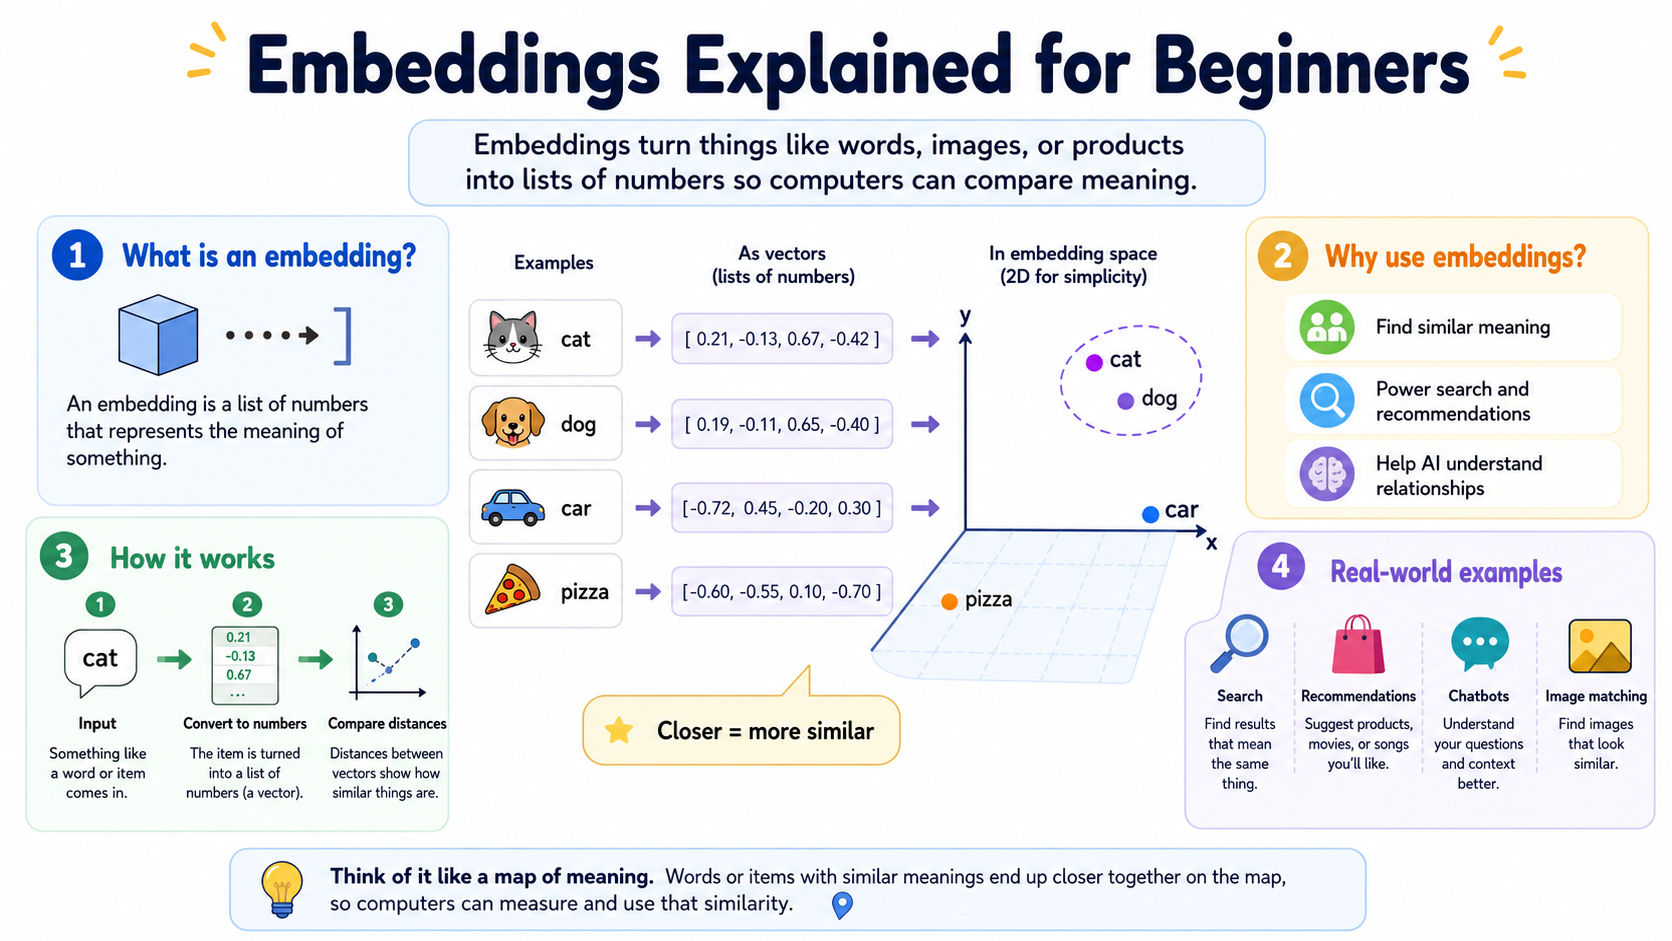

We use `gemini-embedding-001` via the `google.genai` SDK (same API key as before, no extra setup).

**Important detail:** the embedding model accepts a `task_type` hint. Use `RETRIEVAL_DOCUMENT` when indexing your corpus and `RETRIEVAL_QUERY` when embedding a search query. The model produces subtly different vectors for each, optimized for the asymmetric retrieval case (short query → longer document).

In [ ]:
from google import genai
from google.genai import types as genai_types
import numpy as np

# The Client picks up GOOGLE_API_KEY from the environment automatically
genai_client = genai.Client()
EMBEDDING_MODEL = "gemini-embedding-001"


def embed_documents(texts: list[str]) -> np.ndarray:
    """Embed a list of documents for indexing (RETRIEVAL_DOCUMENT task type)."""
    response = genai_client.models.embed_content(
        model=EMBEDDING_MODEL,
        contents=texts,
        config=genai_types.EmbedContentConfig(task_type="RETRIEVAL_DOCUMENT"),
    )
    return np.array([e.values for e in response.embeddings])


# Pre-compute embeddings for all corpus documents (runs once at startup)
DOC_EMBEDDINGS = embed_documents([d["text"] for d in INTERNAL_DOCS])
print(f"✅ Embedded {len(INTERNAL_DOCS)} docs → shape {DOC_EMBEDDINGS.shape}")
print(f"   (each doc is a {DOC_EMBEDDINGS.shape[1]}-dimensional vector)")

✅ Embedded 6 docs → shape (6, 3072)
   (each doc is a 3072-dimensional vector)


This is what an embedding looks like:

In [ ]:
print(DOC_EMBEDDINGS[0])

[-0.0133787   0.02196599  0.00289579 ...  0.00426905 -0.00398293
 -0.01249803]


### 8.3 The retrieval function as a tool

Cosine similarity between the query vector and each document vector. Top-K wins. We wrap this in a function with a clear docstring so ADK can expose it to an agent as a tool.

The docstring is critical: it's what Gemini reads when deciding *when* to call this tool.

In [ ]:
def search_internal_docs(query: str) -> dict:
    """Searches Acme Tech\'s internal HR and policy knowledge base.

    Use this tool whenever you need to answer a question about Acme Tech company
    policies — vacation days, remote work rules, parental leave, compensation,
    benefits, L&D budget, health insurance, or any internal HR matter. The
    knowledge base contains all current company policy documents.

    Args:
        query: A natural-language description of what the employee is asking about.
               Examples: "how many vacation days", "remote work rules",
               "parental leave duration", "L&D budget allowance".

    Returns:
        A dict with the top 3 most relevant policy documents, each with title,
        text, and a similarity score (0 to 1, higher = more relevant).
    """
    # Embed the query (note: RETRIEVAL_QUERY, not RETRIEVAL_DOCUMENT)
    response = genai_client.models.embed_content(
        model=EMBEDDING_MODEL,
        contents=[query],
        config=genai_types.EmbedContentConfig(task_type="RETRIEVAL_QUERY"),
    )
    query_vec = np.array(response.embeddings[0].values)

    # Cosine similarity against all documents
    doc_norms = np.linalg.norm(DOC_EMBEDDINGS, axis=1)
    query_norm = np.linalg.norm(query_vec)
    sims = (DOC_EMBEDDINGS @ query_vec) / (doc_norms * query_norm)

    # Top 3
    top_idx = np.argsort(sims)[::-1][:3]
    return {
        "results": [
            {
                "title": INTERNAL_DOCS[i]["title"],
                "text": INTERNAL_DOCS[i]["text"],
                "similarity": round(float(sims[i]), 3),
            }
            for i in top_idx
        ]
    }

In [ ]:
# Quick sanity check — search without an agent, just the raw tool
test = search_internal_docs("Do we have any Catalan courses?")
print("Top match:", test["results"][0]["title"])
print("Similarity:", test["results"][0]["similarity"])
print("Snippet:  ", test["results"][0]["text"])

Top match: Learning and development budget
Similarity: 0.659
Snippet:   Annual L&D budget: EUR 2,500 per employee, no manager approval required for spend under EUR 500. Covers conferences, courses, books, certifications. Conference travel additionally reimbursed: 2 international conferences per year (flight + hotel + tickets). Internal speaker program: employees who present at external conferences receive EUR 500 bonus per accepted talk. Language learning: full reimbursement for Catalan or Spanish classes for international hires (up to EUR 1,200/year). 10% time policy: every Friday afternoon reserved for learning, side projects, or internal hackathons.


All the top 3 results, and their similarity punctuation:

In [ ]:
test["results"]

[{'title': 'Learning and development budget',
  'text': 'Annual L&D budget: EUR 2,500 per employee, no manager approval required for spend under EUR 500. Covers conferences, courses, books, certifications. Conference travel additionally reimbursed: 2 international conferences per year (flight + hotel + tickets). Internal speaker program: employees who present at external conferences receive EUR 500 bonus per accepted talk. Language learning: full reimbursement for Catalan or Spanish classes for international hires (up to EUR 1,200/year). 10% time policy: every Friday afternoon reserved for learning, side projects, or internal hackathons.',
  'similarity': 0.659},
 {'title': 'Vacation and time off (2026 update)',
  'text': "All full-time employees receive 26 working days of paid vacation per year, above the Spanish legal minimum of 22. Vacation accrues monthly (2.16 days/month) and can be carried over up to 5 days into the next year, expiring on March 31. Additionally: 14 public holiday

Notice that the top result is the AI coding agents note, not because the query mentioned "Acme Cloud" or "internal", but because the **meaning** of the query matched the meaning of that document. That's the magic of embeddings.

### 8.4 The two specialists

Now we define both researchers. Same shape as the agents you've already built, just with different tools and crucially different **descriptions**. The descriptions are what the router will read to decide where to send each query, so they need to be specific.

In [ ]:
# Specialist 1: the web researcher (external info)
# Note: recreated here to avoid single-parent conflicts with earlier sections.
web_researcher = LlmAgent(
    name="web_researcher",
    model=MODEL,
    description=(
        """Answers questions about the external world: tech industry news, product
        announcements, what other companies are doing, market trends, public
        events, or anything that requires searching the web. Does NOT know
        anything about Acme Tech\'s internal policies."""
    ),
    instruction=(
        """You are a web research specialist. Use google_search to find current,
        credible sources. Answer the employee\'s question concisely, citing the
        domains you used (e.g. \'according to techcrunch.com...\')."""
    ),
    tools=[google_search],
)

# Specialist 2: the internal researcher (Acme Tech policies)
internal_researcher = LlmAgent(
    name="internal_researcher",
    model=MODEL,
    description=(
        """Answers questions about Acme Tech\'s internal policies and HR matters:
        vacation days, remote work rules, parental leave, compensation, equity,
        benefits, L&D budget, health insurance. Does NOT know anything about
        the external world or other companies."""
    ),
    instruction=(
        """You are Acme Tech\'s internal HR assistant. Use search_internal_docs to
        find relevant policy documents, then answer the employee\'s question
        based ONLY on what those documents say. Cite the document title for
        each fact (e.g. \'According to the Vacation policy...\'). If the documents
        don\'t contain the answer, say so explicitly — do not guess."""
    ),
    tools=[search_internal_docs],
)

### 8.5 The router

The router is just an `LlmAgent` that has both specialists declared as **tools** (via `AgentTool`). When the LLM router reads the user's question, it sees the two specialist tools (each with its own description) and picks one to call. The chosen specialist runs with its own tools (google_search or RAG), produces an answer, and that answer comes back to the router as the tool's response.

> **Why `AgentTool` instead of `sub_agents`?** Both work for routing, but `sub_agents` injects an internal `transfer_to_agent` function under the hood, and Gemini doesn't allow that to coexist with built-in tools like `google_search` in the same agent. Wrapping each specialist with `AgentTool` sidesteps the limitation. Conceptually the pattern is the same: the LLM picks based on descriptions; only the execution mechanic differs.

In [ ]:
from google.adk.tools.agent_tool import AgentTool

router = LlmAgent(
    name="acme_assistant",
    model=MODEL,
    description="An internal assistant for Acme Tech employees.",
    instruction=(
        """You are Acme Tech\'s internal assistant. Your only job is to route the
        employee\'s question to the right specialist:\n\n

        - If the question is about Acme Tech company policies, HR, benefits,
        vacation, remote work, parental leave, compensation, equity, L&D budget,
        or anything internal to Acme Tech → transfer to `internal_researcher`.\n

        - If the question is about the external world — industry news, other
        companies, market trends, tech announcements, public events → transfer
        to `web_researcher`.\n\n

        Always transfer to a specialist. Do not attempt to answer the question
        yourself. The specialists have access to the right tools."""
    ),
    tools=[
        AgentTool(agent=web_researcher),
        AgentTool(agent=internal_researcher),
    ],
)

### 8.6 Run it

Watch the trace carefully. You'll see:

1. The router (`acme_assistant`) decides where to send the query. This shows up as a `transfer_to_agent` tool call.
2. The chosen specialist runs with its own tool (web_search or search_internal_docs).
3. The specialist's answer becomes the final response.

In [ ]:
# Query 1: pure internal — should route to internal_researcher
print("=" * 60)
print("QUERY 1: How many vacation days do I get per year?")
print("=" * 60)
response = await run_agent(router, "How many vacation days do I get per year?", verbose=True)
print("\n📋 FINAL ANSWER:\n", response)

QUERY 1: How many vacation days do I get per year?
🔧 [acme_assistant] called tool: internal_researcher({'request': 'How many vacation days do I get per year?'})
📥 [acme_assistant] tool response received
💬 [acme_assistant]: According to the Vacation and time off (2026 update) policy, all full-time employees receive 26 working days of paid vac...

📋 FINAL ANSWER:
 According to the Vacation and time off (2026 update) policy, all full-time employees receive 26 working days of paid vacation per year.


In [ ]:
# Query 2: pure external — should route to web_researcher
print("=" * 60)
print("QUERY 2: What did Google announce at I/O 2026?")
print("=" * 60)
response = await run_agent(router, "What did Google announce at I/O 2026?", verbose=True)
print("\n📋 FINAL ANSWER:\n", response)

QUERY 2: What did Google announce at I/O 2026?
🔧 [acme_assistant] called tool: web_researcher({'request': 'What did Google announce at I/O 2026?'})
📥 [acme_assistant] tool response received
💬 [acme_assistant]: At Google I/O 2026, Google unveiled a range of new products and features, with a strong emphasis on artificial intellige...

📋 FINAL ANSWER:
 At Google I/O 2026, Google unveiled a range of new products and features, with a strong emphasis on artificial intelligence and the concept of "agentic" AI. Key announcements include:

**AI and Gemini Updates:**
*   **Gemini 3.5 Flash** was introduced as the new default model for the Gemini app and AI Mode in Search, offering faster and more capable performance for agentic tasks.
*   **Gemini Omni** is a new multimodal generative AI model designed to create anything from any input, combining Gemini's intelligence with generative media models for advanced video, image, and text creation and editing. It will roll out to paid subscribers and t

In [ ]:
# Query 3: comparative — interesting edge case
# The router must pick ONE specialist (it can\'t fan-out). Which does it choose?
print("=" * 60)
print("QUERY 3: How does our parental leave compare to other tech companies?")
print("=" * 60)
response = await run_agent(router, "How does our parental leave compare to other tech companies?", verbose=True)
print("\n📋 FINAL ANSWER:\n", response)

QUERY 3: How does our parental leave compare to other tech companies?
🔧 [acme_assistant] called tool: web_researcher({'request': "How does Acme Tech's parental leave compare to other tech companies?"})
📥 [acme_assistant] tool response received
💬 [acme_assistant]: As an AI assistant, I don't have access to Acme Tech's internal policies, so I cannot directly compare its parental leav...

📋 FINAL ANSWER:
 As an AI assistant, I don't have access to Acme Tech's internal policies, so I cannot directly compare its parental leave to other companies. To make this comparison, you would need to refer to Acme Tech's official parental leave policy documents.

However, I can provide information on parental leave policies at several other major tech companies for your reference:

*   **Google:** Offers 18 weeks of paid parental leave for birthing parents and 12 weeks for non-birthing parents. In cases of complicated pregnancies or premature births, birthing parents can receive additional leave.
*   *

### What just happened (the routing pattern)

You just built the **router pattern**, one of the most common multi-agent architectures in production. The same shape powers:

- Customer support assistants (route to billing, technical, or sales specialists)
- Internal employee assistants (HR, IT, legal, like the one you just built)
- Research assistants (route to academic search, web search, or internal docs)

The key insight: **routing intelligence comes from the LLM reading the `description` field**. You don't write `if/else` logic. You write good descriptions, and the LLM does the rest. This means:

- Better descriptions → better routing decisions
- The router is **only** as smart as your descriptions tell it to be
- Ambiguous queries can route imperfectly (you saw this with query 3)

**Query 3 limitation:** the router can only pick one specialist per query. A "compare X to Y" question genuinely needs both, but our router will pick whichever specialist its LLM thinks is more relevant. There are ways around this (multi-step planning, explicit `ParallelAgent` for comparative queries, or letting the chosen specialist call the other as a tool). See the exercises at the end.

## 9. Try it yourself

A few exercises to extend what you built. Pick one or two:

### 🥉 Easy
- **Change the router's descriptions** to make routing more accurate. For example, make `internal_researcher`'s description explicitly mention "questions starting with \"how many\" or \"what is our\"" and see if routing improves on ambiguous queries.
- **Add more documents** to `INTERNAL_DOCS` (don't forget to re-run `embed_documents`). Cover topics like travel reimbursement, equipment requests, or moonlighting rules. Then ask the router questions about them.
- **Test failure modes:** ask a question that should route to `internal_researcher` but where the policy doesn't exist (e.g. "what's our crypto trading policy?"). Watch how the agent handles it. Does it admit ignorance, or hallucinate?

### 🥈 Medium
- **Add a third specialist:** an `it_helpdesk_researcher` with a custom tool that "looks up" IT issues from a small in-memory dict (e.g. `{"vpn": "Connect via Tailscale...", "printer": "..."}`). Update the router's instruction so it knows when to use the new specialist.
- **Combine routing with the briefing pipeline:** wrap `briefing_generator` (from section 7) as a sub-agent of a new router, alongside `internal_researcher`. Now the system can handle both "research and brief me on X" and "what's our policy on Y" with the same entry point.
- **Switch the router to a different model** while keeping specialists on flash. Routing quality often improves with a smarter router even when specialists stay cheap.

### 🥇 Harder
- **Handle comparative queries.** Right now query 3 ("how does our parental leave compare to other companies?") routes to only one specialist. Build a smarter router that detects comparative questions and calls both specialists. Hint: explore having the router itself be a `SequentialAgent` that first runs a "classifier" sub-agent, then dispatches accordingly.
- **Add metadata filtering** to the RAG tool. Extend `INTERNAL_DOCS` with a `category` field (e.g. "compensation", "time-off", "benefits"). Modify `search_internal_docs` to accept an optional `category` filter and apply it before similarity ranking. Update the agent's instruction to use the filter when the category is clear from the query.
- **Persist the embeddings.** Right now `DOC_EMBEDDINGS` lives in RAM. Save it to disk (pickle, or a real vector DB like `chromadb`) so you don't re-embed every time the notebook restarts.

### 📚 Where to go next

- **LoopAgent**: iterative refinement (writer ↔ critic loops). Great for content quality pipelines.
- **Custom orchestration**: subclass `BaseAgent` when sequential/parallel/loop/routing aren't enough.
- **Vertex AI RAG Engine**: when your corpus outgrows in-memory numpy. Managed retrieval, chunking, hybrid search.
- **Deployment**: ADK ships with `adk web` (local dev UI) and integrates with Vertex AI Agent Engine for production.

### Useful links

- ADK docs: https://google.github.io/adk-docs/
- ADK Python repo: https://github.com/google/adk-python
- Multi-agent patterns guide: https://developers.googleblog.com/developers-guide-to-multi-agent-patterns-in-adk/
- Gemini Embeddings docs: https://ai.google.dev/gemini-api/docs/embeddings